### 1. Data Preparation:
#### Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('heart.csv')
data

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
data.shape

(1025, 14)

### 2. Exploratory Data Analysis (EDA):
#### Perform exploratory data analysis to understand the structure of the dataset.Check for missing values, outliers, and inconsistencies in the data.Visualize the distribution of features, including histograms, box plots, and correlation matrices.


In [4]:
data.isnull().sum()

age         0
gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

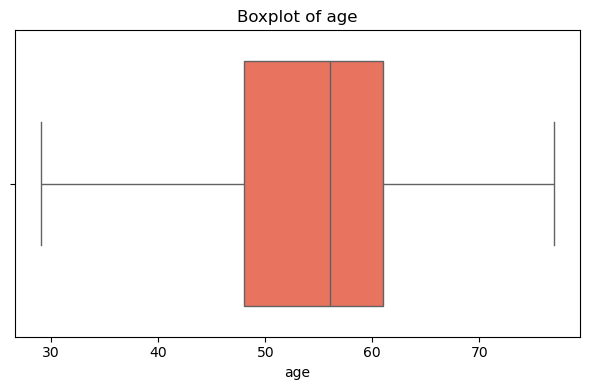

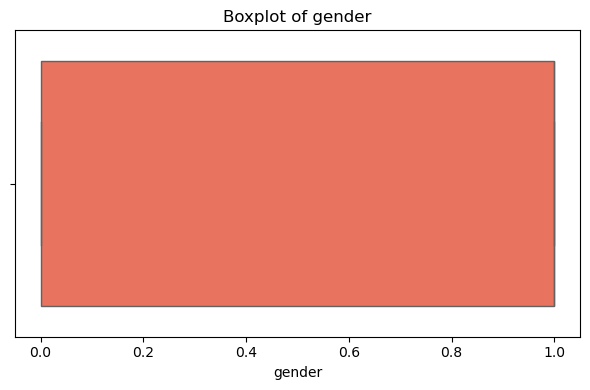

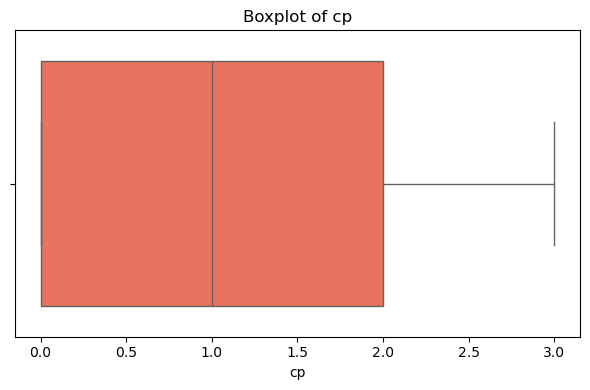

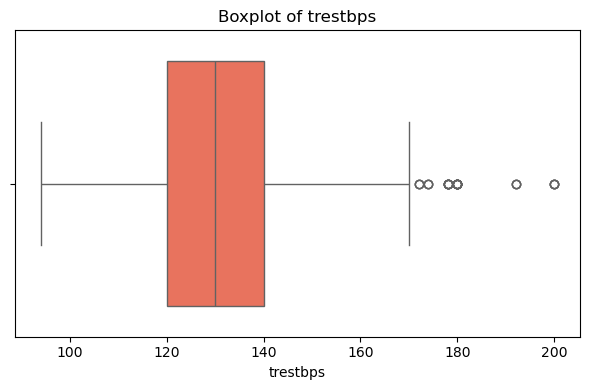

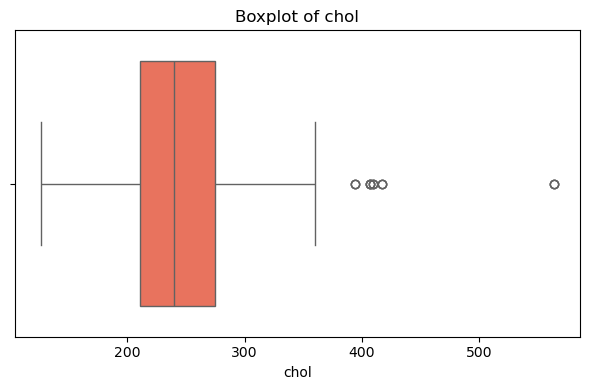

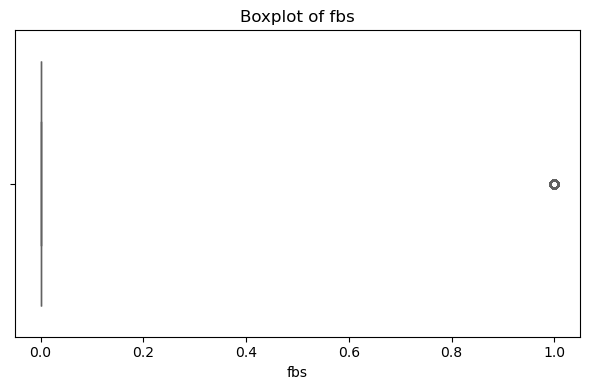

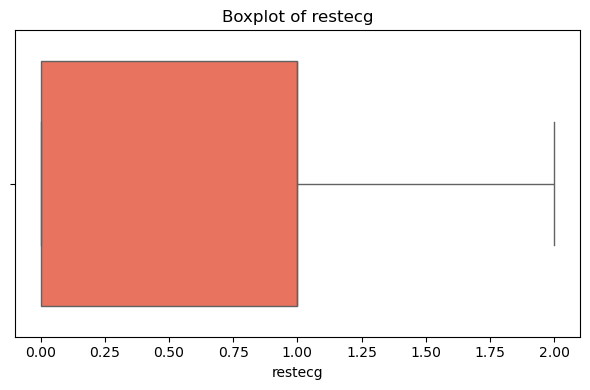

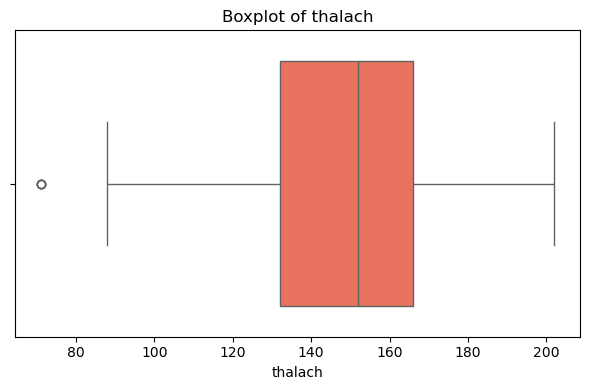

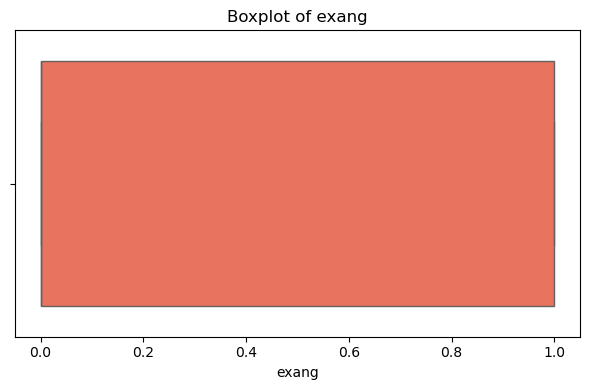

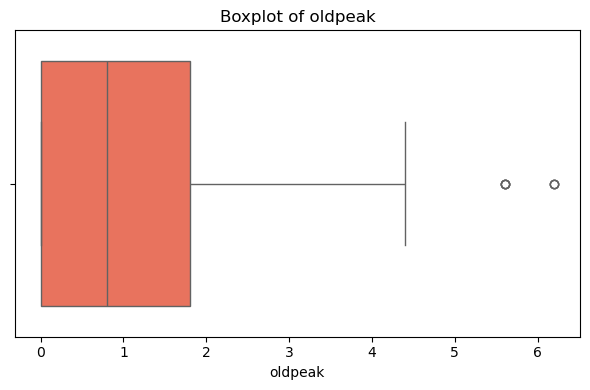

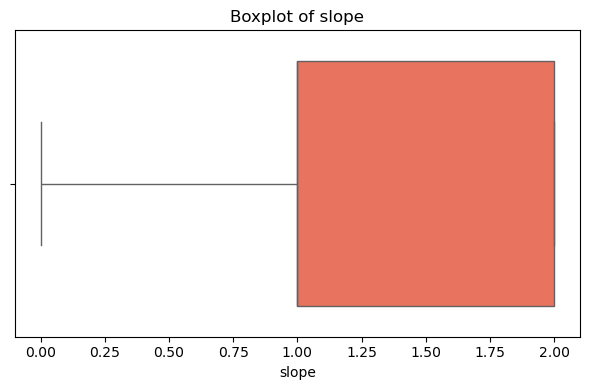

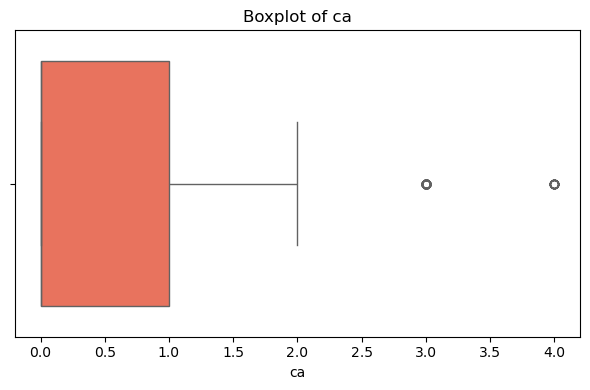

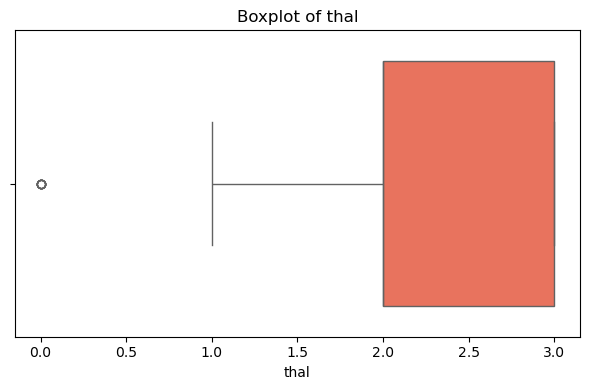

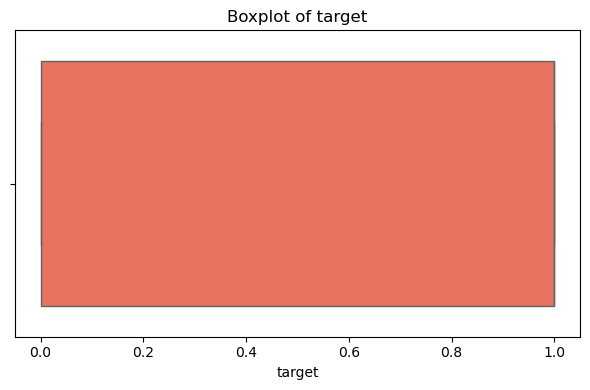

In [5]:
for col in data:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col], color = 'Tomato')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

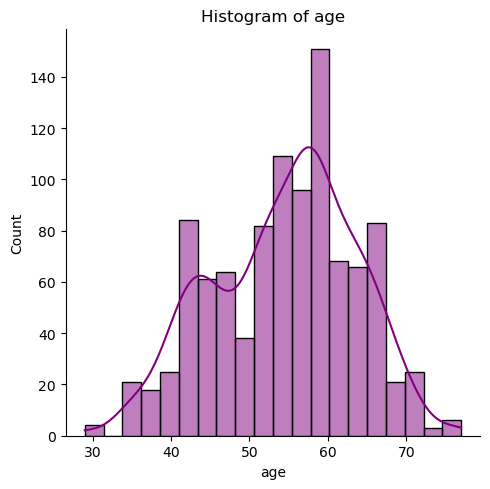

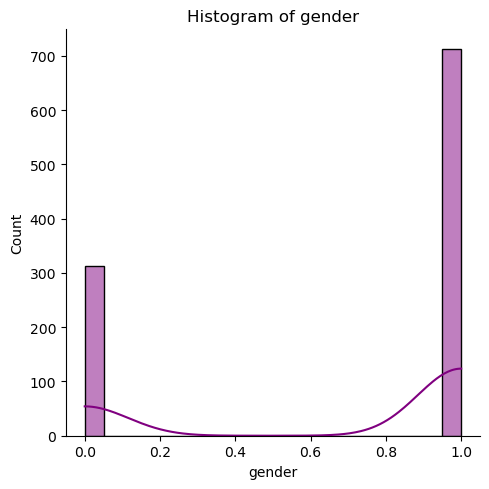

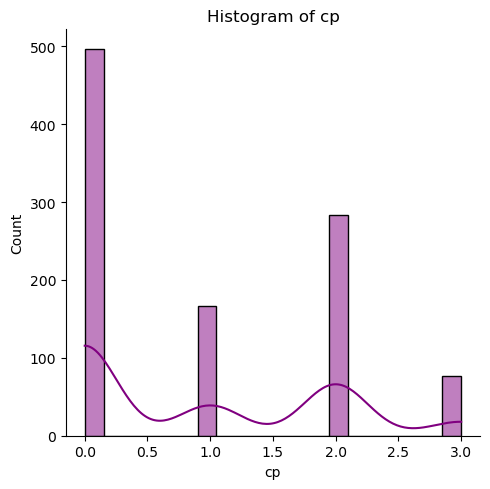

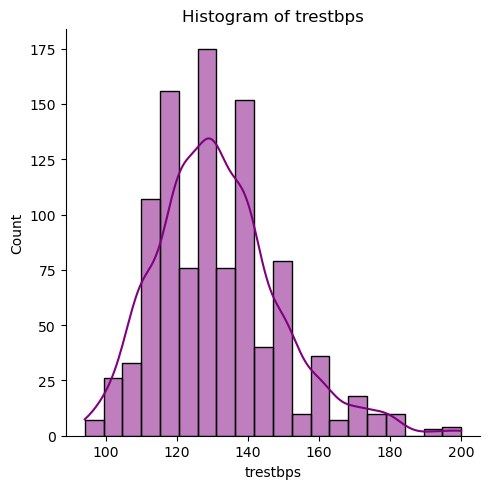

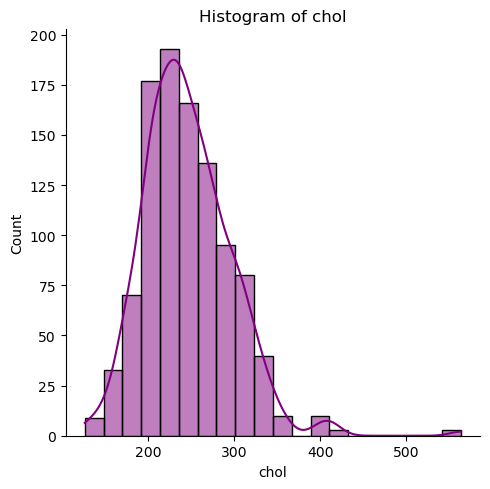

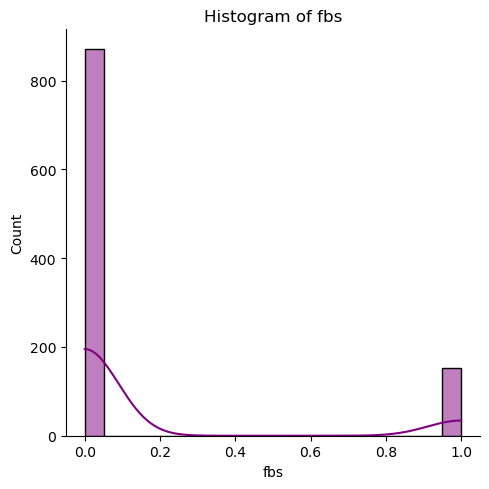

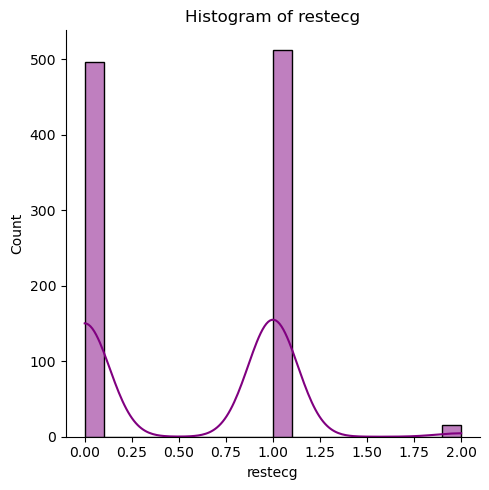

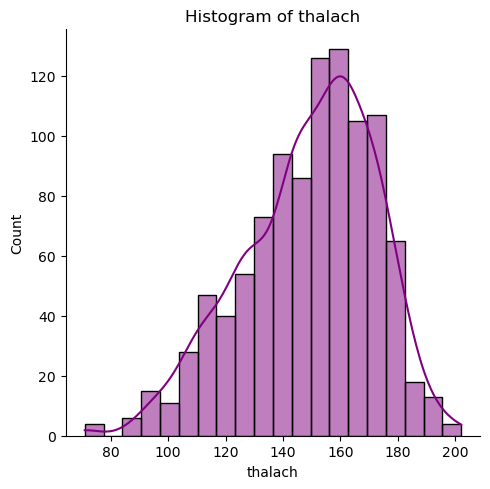

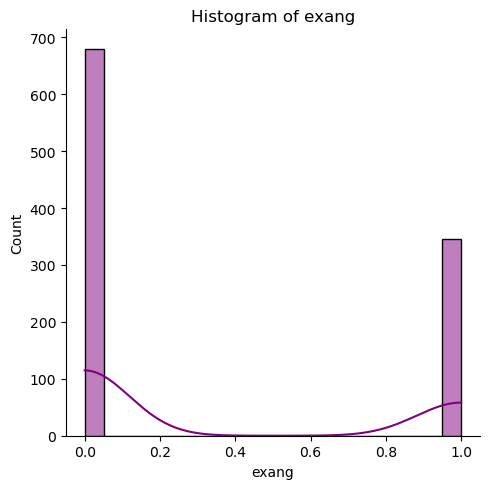

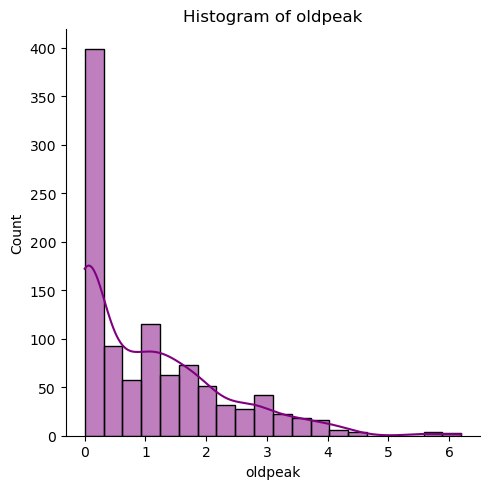

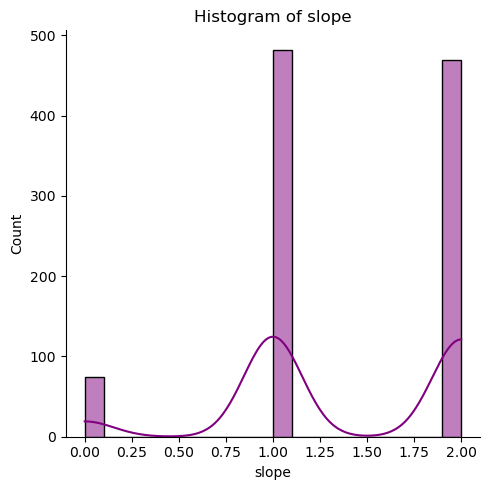

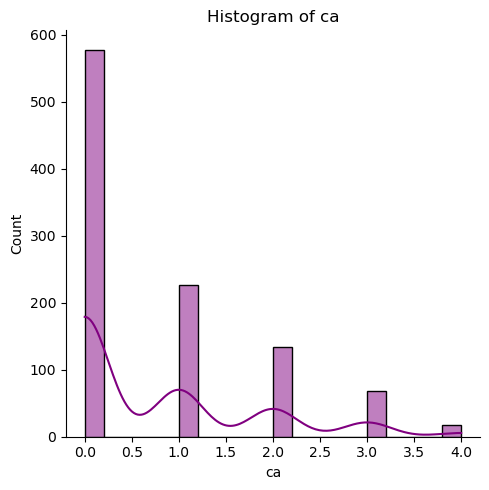

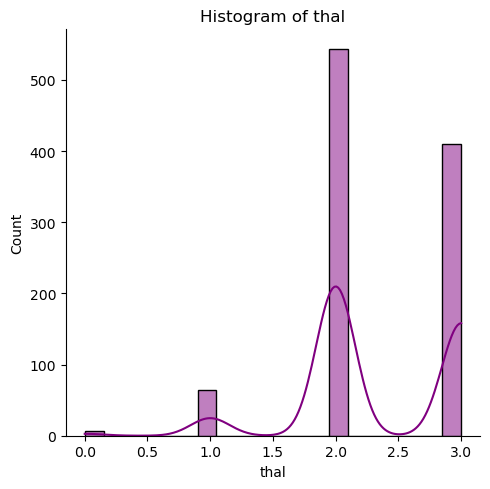

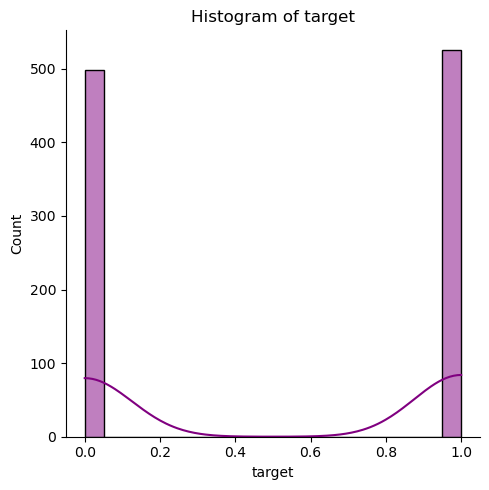

In [6]:
for col in data:
    sns.displot(data=data, x=col, bins=20, kde=True,color='Purple')
    plt.title(f"Histogram of {col}")
    plt.tight_layout()
    plt.show()


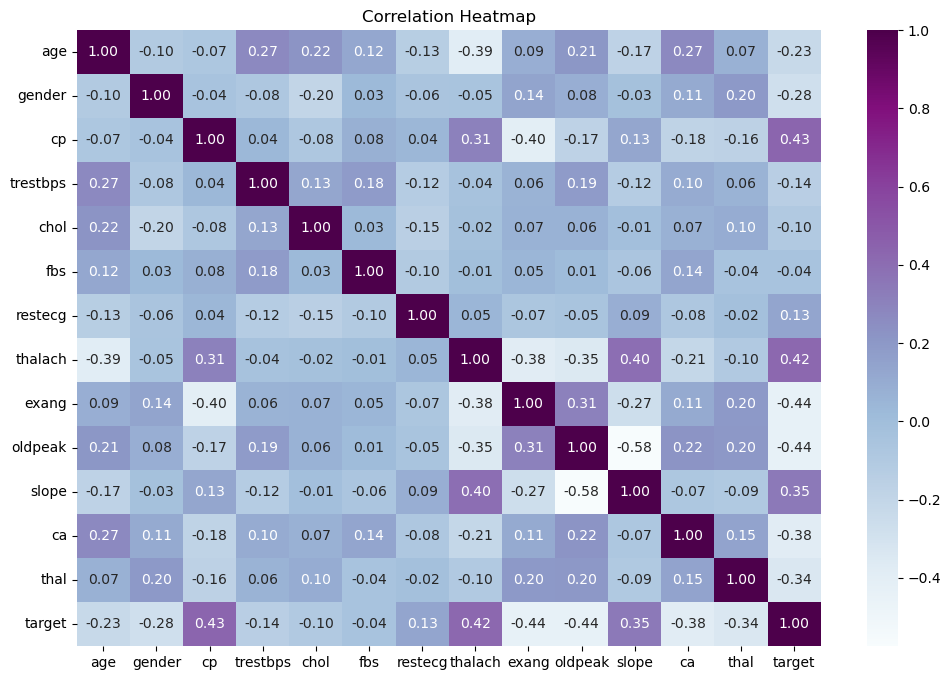

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="BuPu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 3. Feature Engineering:
#### If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.


In [8]:
X = data.drop("target", axis=1)
y = data["target"]

In [9]:
#For this dataset, there are no missing values, and all features are already numeric, feature engineering is not needed

### 4. Decision Tree Classification:
#### Split the dataset into training and testing sets (e.g., using an 80-20 split).Implement a Decision Tree Classification model using a library like scikit-learn.Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import matplotlib.pyplot as plt

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((820, 13), (205, 13), (820,), (205,))

### 5. Hyperparameter Tuning:
#### Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion


In [13]:
clf = DecisionTreeClassifier(max_depth=6, criterion='entropy')
clf.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6)

In [14]:
from sklearn.metrics import confusion_matrix, classification_report

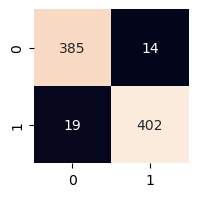

In [15]:
yhat_train = clf.predict(X_train)
cm = confusion_matrix(y_train,yhat_train)
plt.figure(figsize=(2,2))
sns.heatmap(cm,annot=True,fmt='d',cbar=False)
plt.show()

In [16]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       399
           1       0.97      0.95      0.96       421

    accuracy                           0.96       820
   macro avg       0.96      0.96      0.96       820
weighted avg       0.96      0.96      0.96       820



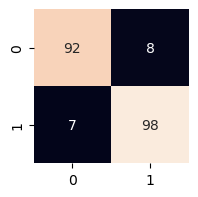

In [17]:
yhat_test = clf.predict(X_test)
cm = confusion_matrix(y_test,yhat_test)
plt.figure(figsize=(2,2))
sns.heatmap(cm, annot=True, cbar=False)
plt.show()

In [18]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       100
           1       0.92      0.93      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



In [19]:
from sklearn.tree import plot_tree
import numpy as np

In [20]:
cnames = data['target'].unique()
cnames

array([0, 1])

In [21]:
fnames = data.columns[:-1]
fnames

Index(['age', 'gender', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

In [22]:
cnames = [str(c) for c in np.unique(y_train)]


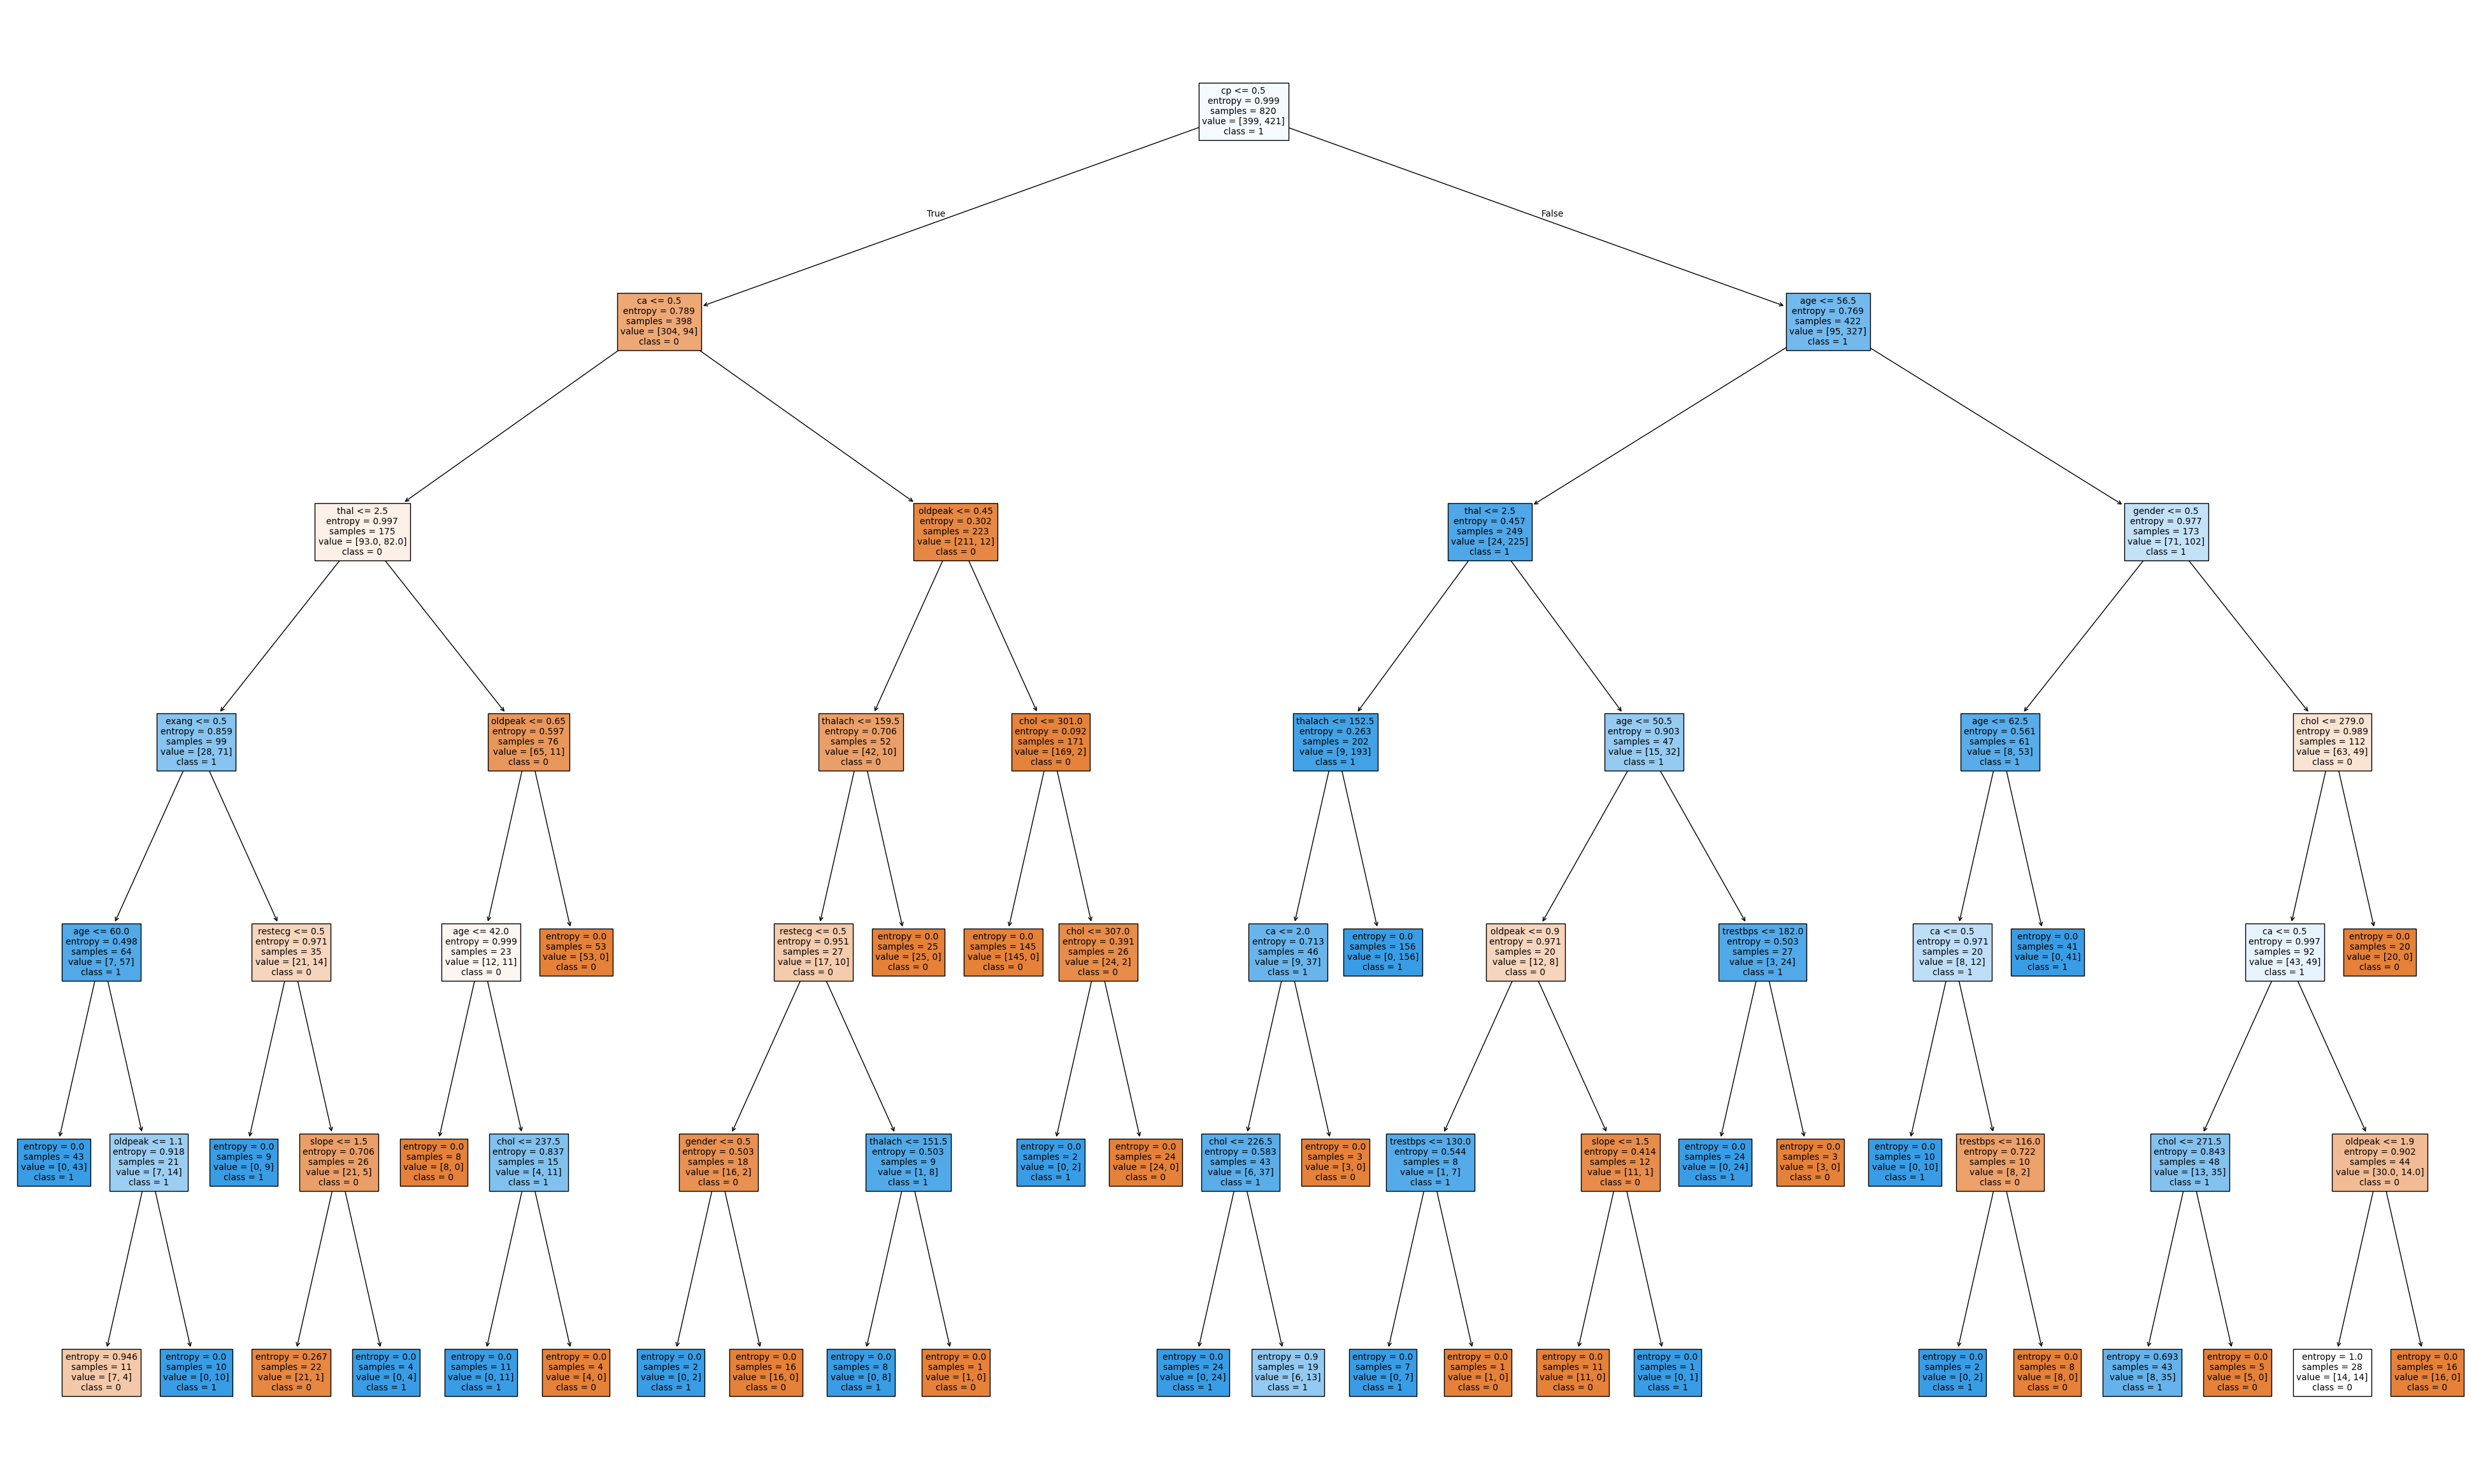

In [23]:
plt.figure(figsize=(50,30))
plot_tree(clf, feature_names=fnames, class_names=cnames, filled=True)
plt.show()

In [24]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

In [25]:
def plot_roc(y,yhat):

    fpr,tpr, thresh = roc_curve(y, yhat)
    auc = roc_auc_score(y, yhat)
    print(f'AUC: {auc}')
    plt.figure(figsize=(3,3))

    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')
    
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1], 'o--')
    plt.show()

AUC: 0.9598908196857941


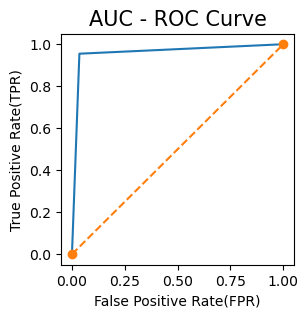

In [26]:
plot_roc(y_train,yhat_train)

AUC: 0.9266666666666667


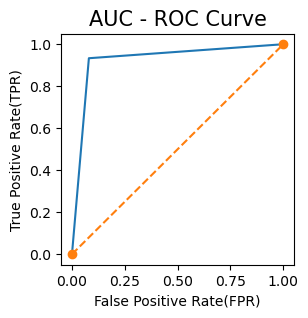

In [27]:
plot_roc(y_test,yhat_test)

In [28]:
clf1= DecisionTreeClassifier(max_depth=4, criterion='entropy')
clf1.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

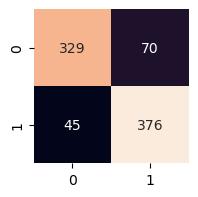

In [29]:
yhat_train1 = clf1.predict(X_train)
cm = confusion_matrix(y_train,yhat_train1)
plt.figure(figsize=(2,2))
sns.heatmap(cm,annot=True,fmt='d',cbar=False)
plt.show()

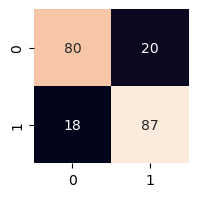

In [31]:
yhat_test1 = clf1.predict(X_test)
cm = confusion_matrix(y_test,yhat_test1)
plt.figure(figsize=(2,2))
sns.heatmap(cm, annot=True, cbar=False)
plt.show()

In [32]:
print(classification_report(y_test,yhat_test1))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       100
           1       0.81      0.83      0.82       105

    accuracy                           0.81       205
   macro avg       0.81      0.81      0.81       205
weighted avg       0.81      0.81      0.81       205



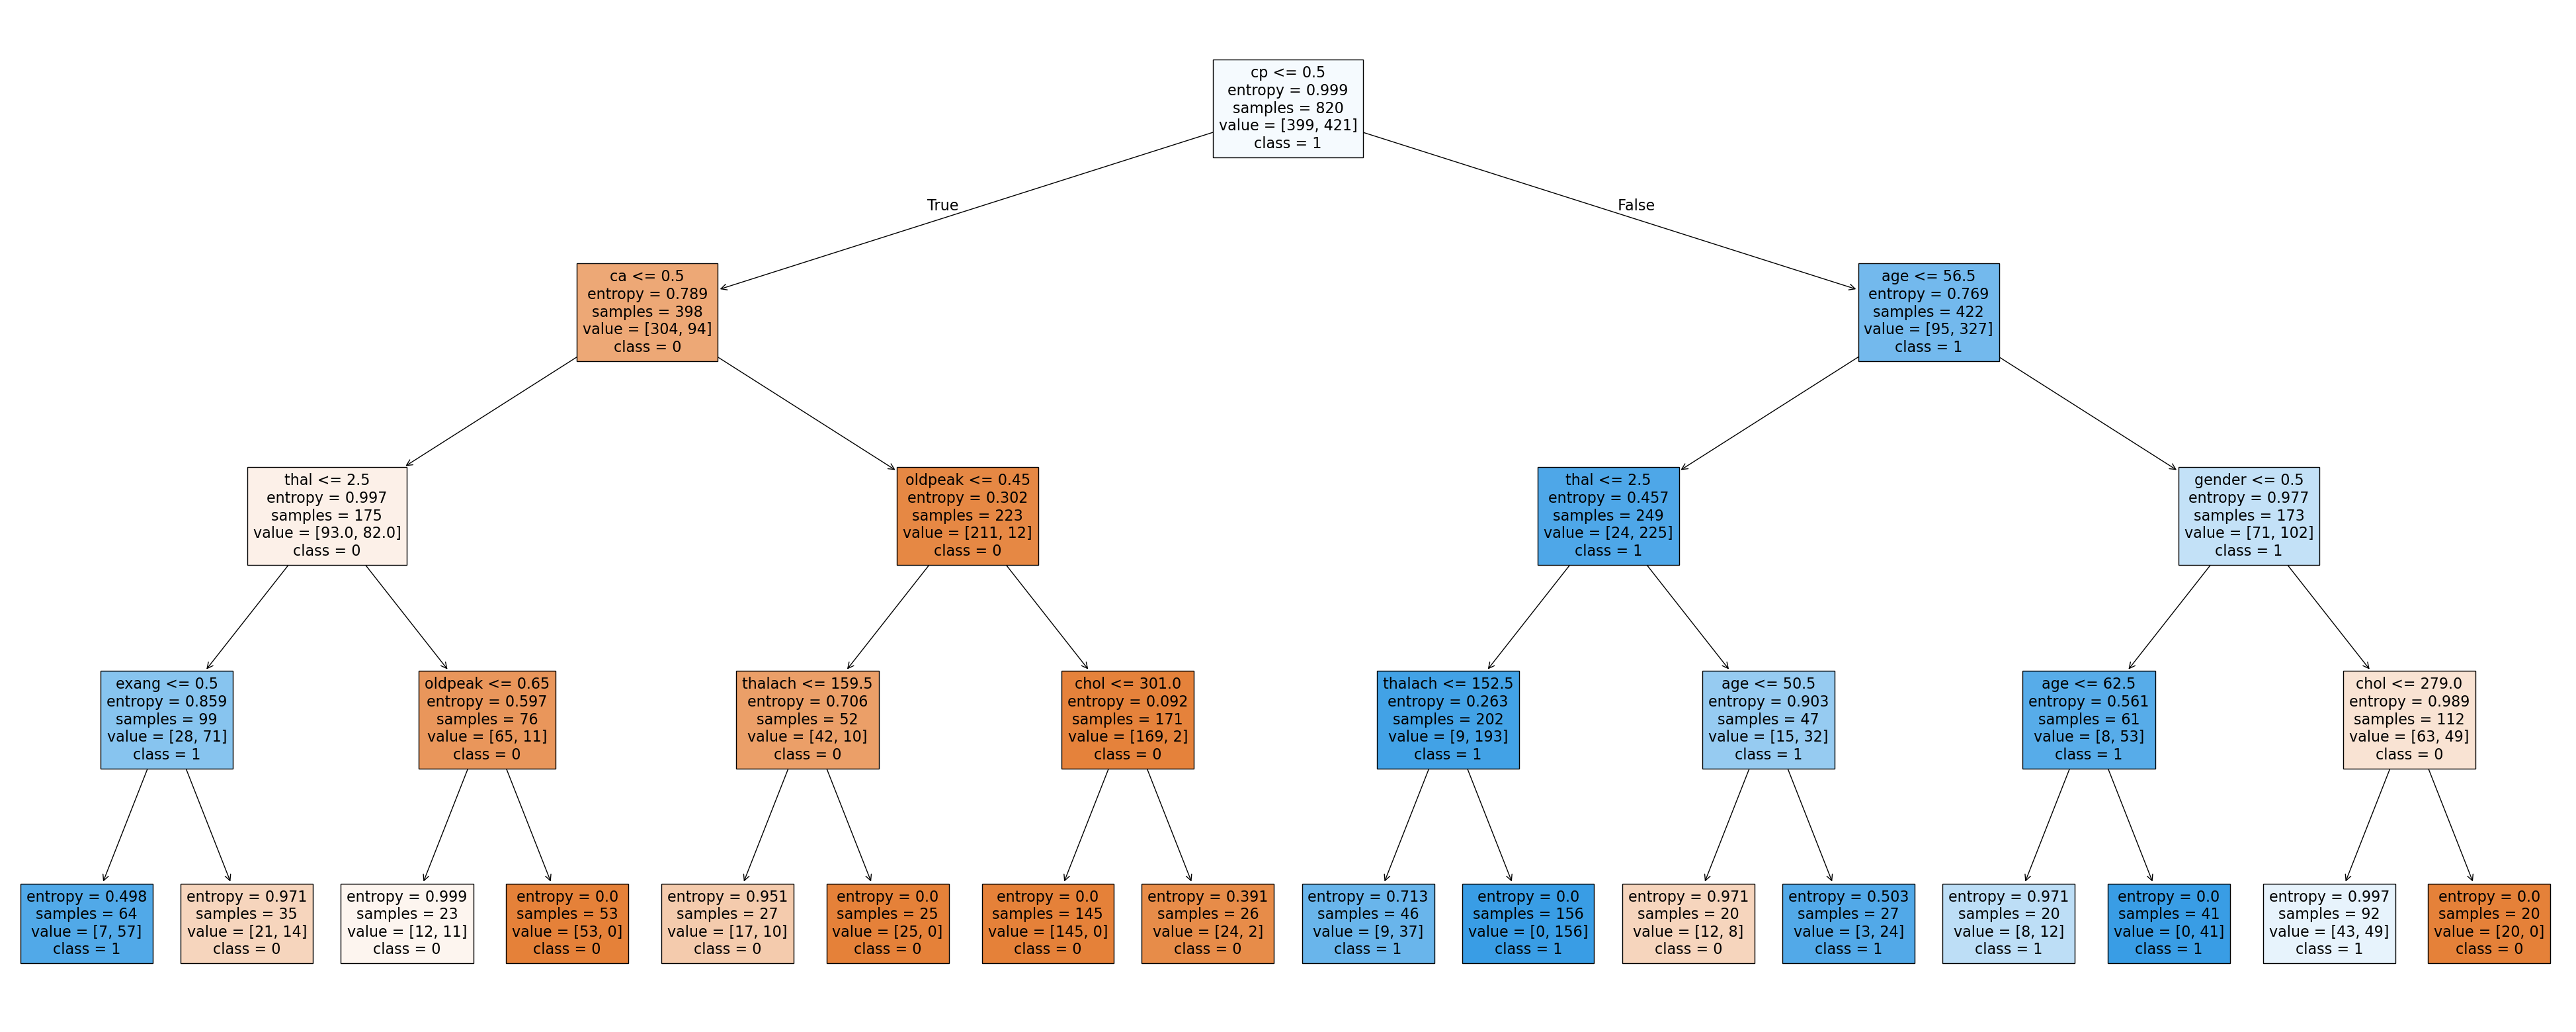

In [33]:
plt.figure(figsize=(50,20))
plot_tree(clf1, feature_names=fnames, class_names=cnames, filled=True)
plt.show()

AUC: 0.8588365212318205


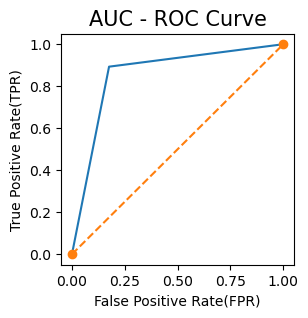

In [34]:
plot_roc(y_train,yhat_train1)

AUC: 0.8142857142857144


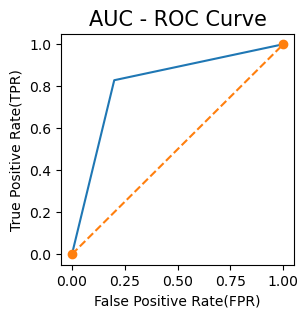

In [35]:
plot_roc(y_test,yhat_test1)

### From the above results we can conclude that the both the built is relavitely a good model with accuracy of 92 and 81 respectively when tested with different depths of the tree

#### The decision tree visualization reveals that chest pain type (cp) is the root node, indicating it's the most important predictor of heart disease. Subsequent splits on number of major vessels (ca), thalassemia status (thal), and ST depression (oldpeak) form the primary decision path. Feature importance analysis confirms cp (25%), oldpeak (20%), and thal (15%) as the top three contributors, providing clear clinical interpretability to the model's predictions.


### 1. Common Decision Tree Hyperparameters
#### max_depth: Limits tree depth. Shallow trees (low value) prevent overfitting but may underfit; deep trees capture patterns but memorize noise.
#### min_samples_split: Minimum samples required to split a node. Higher values create simpler trees, reducing overfitting by avoiding tiny subgroups.
#### min_samples_leaf: Minimum samples required in leaf nodes. Larger values smooth predictions and prevent overfitting to outliers.
#### criterion: Split quality measure (gini or entropy). Gini is faster; entropy may create slightly different splits emphasizing information gain.
#### max_features: Features considered per split. Lower values (sqrt, log2) add randomness, improving generalization like in Random Forests

### 2. Label Encoding vs One-Hot Encoding
#### Label Encoding: Maps categories to integers (Red=0, Green=1, Blue=2). Simple (1 column), but implies false ordinality (Green > Red).
#### One-Hot Encoding: Creates binary columns per category (Red=1/0/0, Green=0/1/0, Blue=0/0/1). No ordering assumption, but increases dimensionality.
#### For Decision Trees: Both work fine since trees don't assume linear relationships.